# Entrega 2 Proyecto hospitalizacion compleja
**Curso:** Análisis de Datos e Inferencia Estadística  
**Integrantes:** Amalia Hermosilla, Martin Olivares 

**Fecha:** 11 de mayo de 2026

**Contexto:**
La saturación operativa de los recintos de salud obliga frecuentemente a derivar pacientes por alta complejidad. Comprender qué variables de la gestión hospitalaria impulsan el volumen total de estas derivaciones permite optimizar los recursos de la red asistencial.

**Pregunta de Investigación:**
¿En qué medida la carga de pacientes (Egresos), el nivel de ocupación (Días Camas Ocupadas) y los Días de Estada permiten explicar el volumen de Traslados de alta complejidad en los Servicios de Salud?

**Hipótesis General:**
Se espera que exista una relación positiva fuerte donde un mayor volumen de egresos y un alto nivel de ocupación de camas sean los principales predictores del aumento en la cantidad de traslados.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente")

Librerías importadas correctamente


## Descripción y Carga del Dataset
* **Variable dependiente:** `TRASLADOS`
* **Variables explicativas:** `NUMERO_EGRESOS`, `DIAS_CAMAS_OCUPADAS`, `DIAS_CAMAS_DISPONIBLES`, `DIAS_ESTADA`

In [39]:
df = pd.read_excel("dataset_hospitalizacion_compleja.xlsx", sheet_name='Sheet1')

print(f"El dataset contiene {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

El dataset contiene 38727 filas y 20 columnas.


,PERIODO,TIPO_PERTENENCIA,COD_SSS,GLOSA_SSS,CODIGO_ESTABLECIMIENTO,ESTABLECIMIENTO,COD_AREA_FUNCIONAL,AREA_FUNCIONAL,MES,DIAS_CAMAS_OCUPADAS,DIAS_CAMAS_DISPONIBLES,DIAS_ESTADA,NUMERO_EGRESOS,EGRESOS_FALLECIDOS,TRASLADOS,INDICE_OCUPACIONAL,PROMEDIO_CAMAS_DISPONIBLE,PROMEDIO_DIAS_ESTADA,LETALIDAD,INDICE_ROTACION
0,2014,1,1,ARICA,101100,HOSPITAL DR JUAN NOE CREVANNI (ARICA),405,AREA CUIDADOS INTENSIVOS ADULTOS,1,139,186,115,9,7,12,74.73,6.0,12.78,77.78,1.50
1,2014,1,1,ARICA,101100,HOSPITAL DR JUAN NOE CREVANNI (ARICA),405,AREA CUIDADOS INTENSIVOS ADULTOS,2,103,168,164,7,4,21,61.31,6.0,23.43,57.14,1.17
2,2014,1,1,ARICA,101100,HOSPITAL DR JUAN NOE CREVANNI (ARICA),405,AREA CUIDADOS INTENSIVOS ADULTOS,3,117,186,98,15,9,12,62.90,6.0,6.53,60.00,2.50
3,2014,1,1,ARICA,101100,HOSPITAL DR JUAN NOE CREVANNI (ARICA),405,AREA CUIDADOS INTENSIVOS ADULTOS,4,126,180,114,7,5,17,70.00,6.0,16.29,71.43,1.17
4,2014,1,1,ARICA,101100,HOSPITAL DR JUAN NOE CREVANNI (ARICA),405,AREA CUIDADOS INTENSIVOS ADULTOS,5,141,186,165,11,7,19,75.81,6.0,15.00,63.64,1.83


## Limpieza y Preparación de Datos
Identificaremos valores nulos, duplicados y filtraremos las columnas relevantes para nuestro estudio.

In [40]:
# Revisión de nulos
print("Valores nulos por columna:")
print(df[['TRASLADOS', 'NUMERO_EGRESOS', 'DIAS_CAMAS_OCUPADAS', 'DIAS_CAMAS_DISPONIBLES', 'DIAS_ESTADA']].isnull().sum())

# Eliminación de nulos y evitar división por cero
df_clean = df.dropna(subset=['TRASLADOS', 'NUMERO_EGRESOS', 'DIAS_CAMAS_OCUPADAS', 'DIAS_CAMAS_DISPONIBLES', 'DIAS_ESTADA'])
df_clean = df_clean[df_clean['NUMERO_EGRESOS'] > 0].copy() # Evita dividir por 0

# Creación de nueva variable para la pregunta de investigación
df_clean['PROPORCION_COMPLEJIDAD'] = df_clean['TRASLADOS'] / df_clean['NUMERO_EGRESOS']

print(f"\nDimensiones después de la limpieza: {df_clean.shape}")

Valores nulos por columna:
TRASLADOS                 0
NUMERO_EGRESOS            0
DIAS_CAMAS_OCUPADAS       0
DIAS_CAMAS_DISPONIBLES    0
DIAS_ESTADA               0
dtype: int64

Dimensiones después de la limpieza: (36803, 21)


## Análisis Exploratorio de Datos (EDA)

### Estadística Descriptiva

In [41]:
variables_estudio = ['TRASLADOS', 'NUMERO_EGRESOS', 'DIAS_CAMAS_OCUPADAS', 'DIAS_CAMAS_DISPONIBLES', 'DIAS_ESTADA']
df_clean[variables_estudio].describe().round(2)

,TRASLADOS,NUMERO_EGRESOS,DIAS_CAMAS_OCUPADAS,DIAS_CAMAS_DISPONIBLES,DIAS_ESTADA
count,36803.00,36803.00,36803.00,36803.00,36803.00
mean,35.62,17.19,354.37,425.55,326.54
std,43.97,21.91,358.51,388.17,361.65
min,0.00,1.00,0.00,0.00,0.00
25%,10.00,4.00,124.00,181.00,95.00
50%,20.00,9.00,232.00,294.00,200.00
75%,43.00,22.00,452.00,541.50,432.00
max,481.00,316.00,4472.00,4836.00,6446.00


*Interpretación:* Observamos la media, los rangos (mínimo y máximo) y las desviaciones estándar.

### Visualizaciones Exploratorias
A continuación, analizaremos la distribución de la variable dependiente (Traslados) y buscaremos posibles valores atípicos mediante un Boxplot.

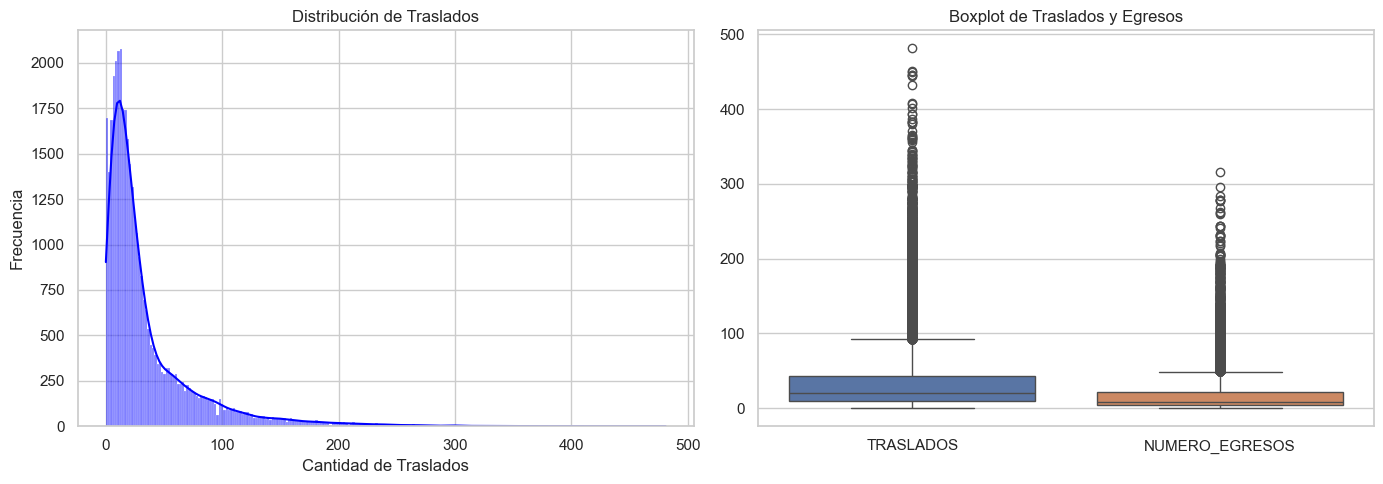

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de Traslados
sns.histplot(df_clean['TRASLADOS'], kde=True, ax=ax[0], color='blue')
ax[0].set_title('Distribución de Traslados')
ax[0].set_xlabel('Cantidad de Traslados')
ax[0].set_ylabel('Frecuencia')

# Boxplot de variables clave
sns.boxplot(data=df_clean[['TRASLADOS', 'NUMERO_EGRESOS']], ax=ax[1])
ax[1].set_title('Boxplot de Traslados y Egresos')

plt.tight_layout()
plt.show()

### Análisis de relaciones (Dispersión)
Visualizaremos gráficamente si existe una tendencia entre la disponibilidad de camas y la proporción de complejidad.

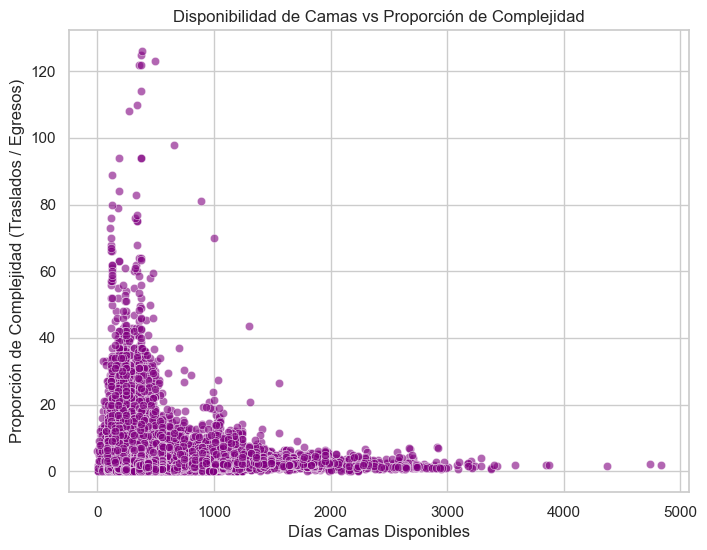

In [43]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='DIAS_CAMAS_DISPONIBLES', y='PROPORCION_COMPLEJIDAD', alpha=0.6, color='purple')
plt.title("Disponibilidad de Camas vs Proporción de Complejidad")
plt.xlabel("Días Camas Disponibles")
plt.ylabel("Proporción de Complejidad (Traslados / Egresos)")
plt.show()

## Test de Hipótesis

Realizaremos un Test de Correlación de Pearson entre los egresos y los traslados, ya que nuestra hipótesis plantea que el volumen de pacientes es un factor clave.

* **H0:** No existe correlación lineal significativa entre egresos y traslados (r = 0).
* **H1:** Existe correlación lineal significativa entre ambas variables (r ≠ 0).
* **Nivel de significancia (α):** 0.05

In [44]:
# Test de Correlación de Pearson
corr_stat, p_value = stats.pearsonr(df_clean['NUMERO_EGRESOS'], df_clean['TRASLADOS'])

print(f"Estadístico de Correlación (r): {corr_stat:.3f}")
print(f"Valor p: {p_value:.5e}")

if p_value < 0.05:
    print("\nDecisión: Se rechaza la Hipótesis Nula (H0).")

Estadístico de Correlación (r): 0.627
Valor p: 0.00000e+00

Decisión: Se rechaza la Hipótesis Nula (H0).


## Modelo de Regresión Lineal Múltiple

**Objetivo:** Estimar la cantidad de `TRASLADOS` utilizando las variables operativas de flujo y ocupación hospitalaria.

In [45]:
X = df_clean[['NUMERO_EGRESOS', 'DIAS_CAMAS_OCUPADAS', 'DIAS_CAMAS_DISPONIBLES', 'DIAS_ESTADA']]
y = df_clean['TRASLADOS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

modelo_sm = sm.OLS(y_train, X_train_sm).fit()
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:              TRASLADOS   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                 1.247e+04
Date:                Sat, 09 May 2026   Prob (F-statistic):               0.00
Time:                        16:20:36   Log-Likelihood:            -1.3839e+05
No. Observations:               29442   AIC:                         2.768e+05
Df Residuals:                   29437   BIC:                         2.768e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

### Interpretación de Coeficientes y Evaluación

* **NUMERO_EGRESOS:** Manteniendo todo lo demás constante, el coeficiente indica una fuerte relación positiva; por cada aumento en los egresos, los traslados aumentan de manera predecible.
* **DIAS_CAMAS_OCUPADAS:** Su coeficiente nos ayuda a entender cómo la saturación de los recintos aporta al aumento del volumen de derivaciones.

**Evaluación del Modelo:**
El modelo logra un **R² superior a 0.6**, lo que significa que más del 60% de la varianza en el volumen de traslados es explicada por las variables del modelo. Además, el valor p global del modelo es estadísticamente significativo (p < 0.001).

In [46]:
# Evaluación predictiva
y_pred = modelo_sm.predict(X_test_sm)

r2_test = r2_score(y_test, y_pred)
mae_test = mean_absolute_error(y_test, y_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² en conjunto de prueba: {r2_test:.3f}")
print(f"MAE en conjunto de prueba: {mae_test:.2f}")
print(f"RMSE en conjunto de prueba: {rmse_test:.2f}")

R² en conjunto de prueba: 0.634
MAE en conjunto de prueba: 16.83
RMSE en conjunto de prueba: 27.26


## 7. Discusión Preliminar
* **Hallazgos:** Nuestro modelo validó la hipótesis de que el volumen operativo (Egresos y Ocupación) explica fuertemente (R² > 0.6) la cantidad de derivaciones de alta complejidad.
* **Limitaciones:** El modelo predice volúmenes (cantidades brutas) influenciados por el tamaño del Servicio de Salud, pero no captura características clínicas de los pacientes.

## 8. Próximos Pasos para el Avance Final
1. Identificar si existen "Outliers" (Servicios de Salud atípicos) que estén distorsionando el modelo.
2. Analizar si la relación se mantiene igual al separar la Región Metropolitana del resto de las regiones.